In [1]:
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transformation = transforms.Compose([
    transforms.Resize((384, 384)), #pre-train size
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), #pre-train want normalize
])

realwaste_img = datasets.ImageFolder("realwaste-main/RealWaste/", transform=transformation)

In [3]:
# Get number of classes in the dataset
num_classes = len(realwaste_img.classes)
print(f"Dataset contains {num_classes} classes: {realwaste_img.classes}")

Dataset contains 9 classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [4]:
# Split dataset into training and test set
train_ratio = 0.7
train_size = int(train_ratio * len(realwaste_img))
test_size = len(realwaste_img) - train_size
train_dataset, test_dataset = random_split(realwaste_img,[train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [5]:
def show_image(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1)
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

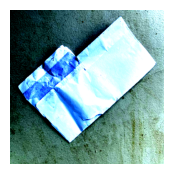

Label: Paper


In [6]:
images, labels = next(iter(train_loader))
show_image(images[0])
print(f"Label: {realwaste_img.classes[labels[0]]}")

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

In [8]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [9]:
def train(model, train_loader, loss_fn, optimizer, epochs, is_pretrain=False):
    if is_pretrain:
        model.train()

    history_loss = []

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images) # y_hat
            loss = loss_fn(outputs, labels) # error
            optimizer.zero_grad() # reset to new round
            loss.backward() # back
            optimizer.step() # learn

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        history_loss.append(avg_loss)
        print(f"epoch {epoch+1}  loss = {avg_loss}")

    return history_loss

def evaluate(model, test_loader, is_pretrain=False):
    if is_pretrain:
        model.oval()
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            
    print("Accuracy:", correct / len(test_dataset))

In [10]:
def plot_single(data, data_lab, xlab, ylab, tit, save_name, save_dir="Results/"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(np.arange(len(data)), data, lw=2, label=data_lab)
    ax.set(xlabel=xlab, ylabel=ylab, title=tit)
    fig.savefig(save_dir + save_name)
    # plt.show()

def plot_compare(data_1, data_1_lab, data_2, data_2_lab, xlab, ylab, tit, save_name, save_dir="Results/"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(np.arange(len(data_1)), data_1, lw=2, label=data_1_lab)
    ax.plot(np.arange(len(data_2)), data_2, lw=2, label=data_2_lab)
    ax.set(xlabel=xlab, ylabel=ylab, title=tit)
    # ax.set_ylim(top=1)
    # ax.set_xlim(xmax=2000, xmin=0)
    plt.legend()
    # plt.show()
    fig.savefig(save_dir + save_name)

In [16]:
model_1 = nn.Sequential(
    nn.Conv2d(3, 16, 3),
    nn.ReLU(),
    nn.Conv2d(16, 32, 3),
    nn.ReLU(),
    nn.Conv2d(32, 64, 3),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3),
    nn.ReLU(),

    nn.Conv2d(64, num_classes, 3),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
).to(device)

loss_fn_1   = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)

m1loss = train(model_1, train_loader, loss_fn_1, optimizer_1, 5)
evaluate(model_1, test_loader)
plot_single(m1loss, "Loss", "Epochs", "Loss", "Basic Model Loss", "m1.png")

KeyboardInterrupt: 

In [12]:
from collections import Counter

model_1.eval()
preds = []
with torch.no_grad():
    for images, labels in test_loader:
        preds += model_1(images.to(device)).argmax(1).cpu().tolist()

print(Counter(realwaste_img.classes[p] for p in preds))

Counter({'Plastic': 396, 'Miscellaneous Trash': 376, 'Vegetation': 260, 'Food Organics': 180, 'Metal': 138, 'Paper': 37, 'Glass': 31, 'Cardboard': 8})


In [ ]:
model_2 = nn.Sequential(
    nn.Conv2d(3, 16, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(64, 64, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, num_classes, 3),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
).to(device)

loss_fn_2   = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.0001)

m2loss = train(model_2, train_loader, loss_fn_2, optimizer_2, 100)
evaluate(model_2, test_loader)
plot_single(m2loss, "Loss", "Epochs", "Loss", "More Detail Model Loss", "m2.png")
plot_compare(m1loss, "Basic", m2loss, "Advanced", "Epochs", "Loss", "Comparison basic and more detailed model", "cmp1-2.png")

epoch 1  loss = 2.1175188513902516
epoch 2  loss = 2.019942352404961
epoch 3  loss = 1.9451919473134553
Accuracy: 0.3085553997194951


In [18]:
from torchvision.models import RegNet_Y_16GF_Weights

pretrained_weights = RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1

pretrained_model = models.regnet_y_16gf(weights=pretrained_weights)
# pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, num_classes) # in=idc, out_feature = current num classes
# pretrained_model = pretrained_model.to(device)
# loss_fn_3 = nn.CrossEntropyLoss()

# # ---------- ขั้น 1: Feature extraction (เทรนแค่ fc) ----------
# for param in pretrained_model.parameters():
#     param.requires_grad = False
# for param in pretrained_model.fc.parameters():
#     param.requires_grad = True

# optimizer_3 = torch.optim.Adam(pretrained_model.fc.parameters(), lr=0.001)
# train(pretrained_model, train_loader, loss_fn_3, optimizer_3, 3)

# # ---------- ขั้น 2: Fine-tune block4 + fc ----------
# for param in pretrained_model.trunk_output.block4.parameters():
#     param.requires_grad = True

# optimizer_3 = torch.optim.Adam(
#     [p for p in pretrained_model.parameters() if p.requires_grad], lr=0.0001
# )

# m3loss = train(pretrained_model, train_loader, loss_fn_3, optimizer_3, 100)
# evaluate(pretrained_model, test_loader)
# plot_single(m3loss, "Loss", "Epochs", "Loss", "More Detail Model Loss", "m3.png")

In [24]:
for name, module in pretrained_model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"{name:23s} {n:>12,} weights")

    if name == "trunk_output":
        for name, module in pretrained_model.trunk_output.named_children():
            n = sum(p.numel() for p in module.parameters())
            print(f"  trunk_output.{name:8s} {n:>12,} weights")

stem                             928 weights
trunk_output              80,564,212 weights
  trunk_output.block1        648,768 weights
  trunk_output.block2      3,777,032 weights
  trunk_output.block3     54,604,200 weights
  trunk_output.block4     21,534,212 weights
avgpool                            0 weights
fc                         3,025,000 weights
